<a href="https://www.kaggle.com/code/lalit7881/battery-remaining-useful-life-rul-100?scriptVersionId=356170231" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/razanihababdellatif/battery-remaining-useful-life-rul-dataset/battery_metadata.csv
/kaggle/input/datasets/razanihababdellatif/battery-remaining-useful-life-rul-dataset/battery_observations.csv
/kaggle/input/datasets/razanihababdellatif/battery-remaining-useful-life-rul-dataset/train_batteries.csv
/kaggle/input/datasets/razanihababdellatif/battery-remaining-useful-life-rul-dataset/test_batteries.csv
/kaggle/input/datasets/razanihababdellatif/battery-remaining-useful-life-rul-dataset/validation_batteries.csv


In [2]:
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # For plt if only imported the pyplot module

# Ensure inline plotting in Jupyter
%matplotlib inline

# Import scikit-learn libraries for modelling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Set a style for seaborn
sns.set(style='whitegrid')

In [3]:
from pathlib import Path

# Dynamically resolve the data file path
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Resolve file paths for each dataset
train_batteries_path = resolve_data_file(file_name='train_batteries.csv', suffixes=['.csv'])
validation_batteries_path = resolve_data_file(file_name='validation_batteries.csv', suffixes=['.csv'])
test_batteries_path = resolve_data_file(file_name='test_batteries.csv', suffixes=['.csv'])
battery_metadata_path = resolve_data_file(file_name='battery_metadata.csv', suffixes=['.csv'])
battery_observations_path = resolve_data_file(file_name='battery_observations.csv', suffixes=['.csv'])

# Load the datasets into pandas DataFrames
# Note: train/validation/test batteries files are tab-delimited, while metadata and observations are comma-delimited.
train_batteries = pd.read_csv(train_batteries_path, delimiter='T', engine='python')
validation_batteries = pd.read_csv(validation_batteries_path, delimiter='T', engine='python')
test_batteries = pd.read_csv(test_batteries_path, delimiter='T', engine='python')
battery_metadata = pd.read_csv(battery_metadata_path, delimiter=',')
battery_obs_df = pd.read_csv(battery_observations_path, delimiter=',')

In [4]:
# Convert the 'timestamp' column to datetime (if not already converted)
if 'timestamp' in battery_obs_df.columns:
    # Using errors='coerce' to ensure that any problematic date strings become NaT
    battery_obs_df['timestamp'] = pd.to_datetime(battery_obs_df['timestamp'], errors='coerce')

# Check and report missing values in the key DataFrames
print('Missing values in battery_metadata:')
print(battery_metadata.isnull().sum())

print('\nMissing values in battery_observations:')
print(battery_obs_df.isnull().sum())

# Depending on the findings, you might decide to impute, drop, or further investigate these missing values.

Missing values in battery_metadata:
battery_id              0
chemistry               0
manufacturer            0
climate_zone            0
nominal_capacity_kwh    0
usage_strategy          0
dataset_split           0
dtype: int64

Missing values in battery_observations:
battery_id                             0
timestamp                              0
cycle_index                            0
battery_age_days                       0
time_since_previous_cycle_hours        0
equivalent_full_cycles                 0
soc_start_pct                          0
soc_end_pct                            0
depth_of_discharge_pct                 0
high_soc_exposure_fraction             0
low_soc_exposure_fraction              0
charge_c_rate                          0
discharge_c_rate                       0
charge_current_a                       0
discharge_current_a                    0
charge_duration_min                    0
discharge_duration_min                 0
energy_discharged_kwh          

## EDA

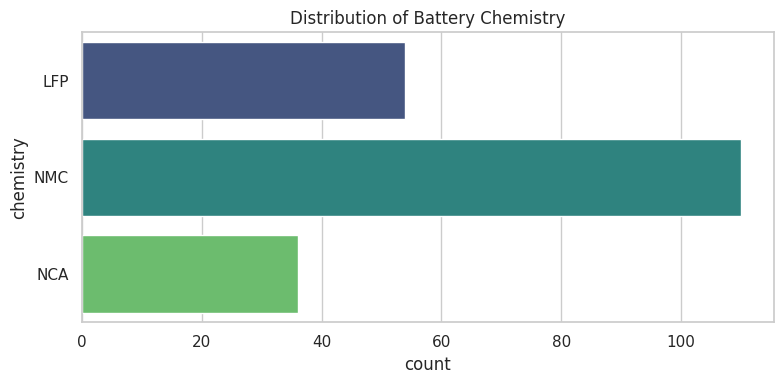

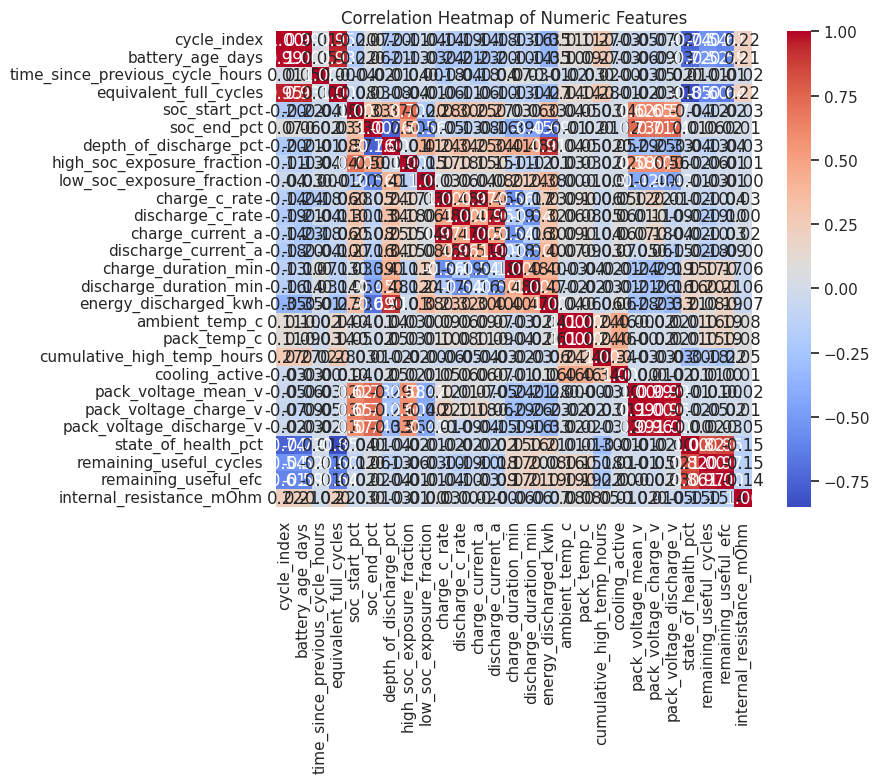

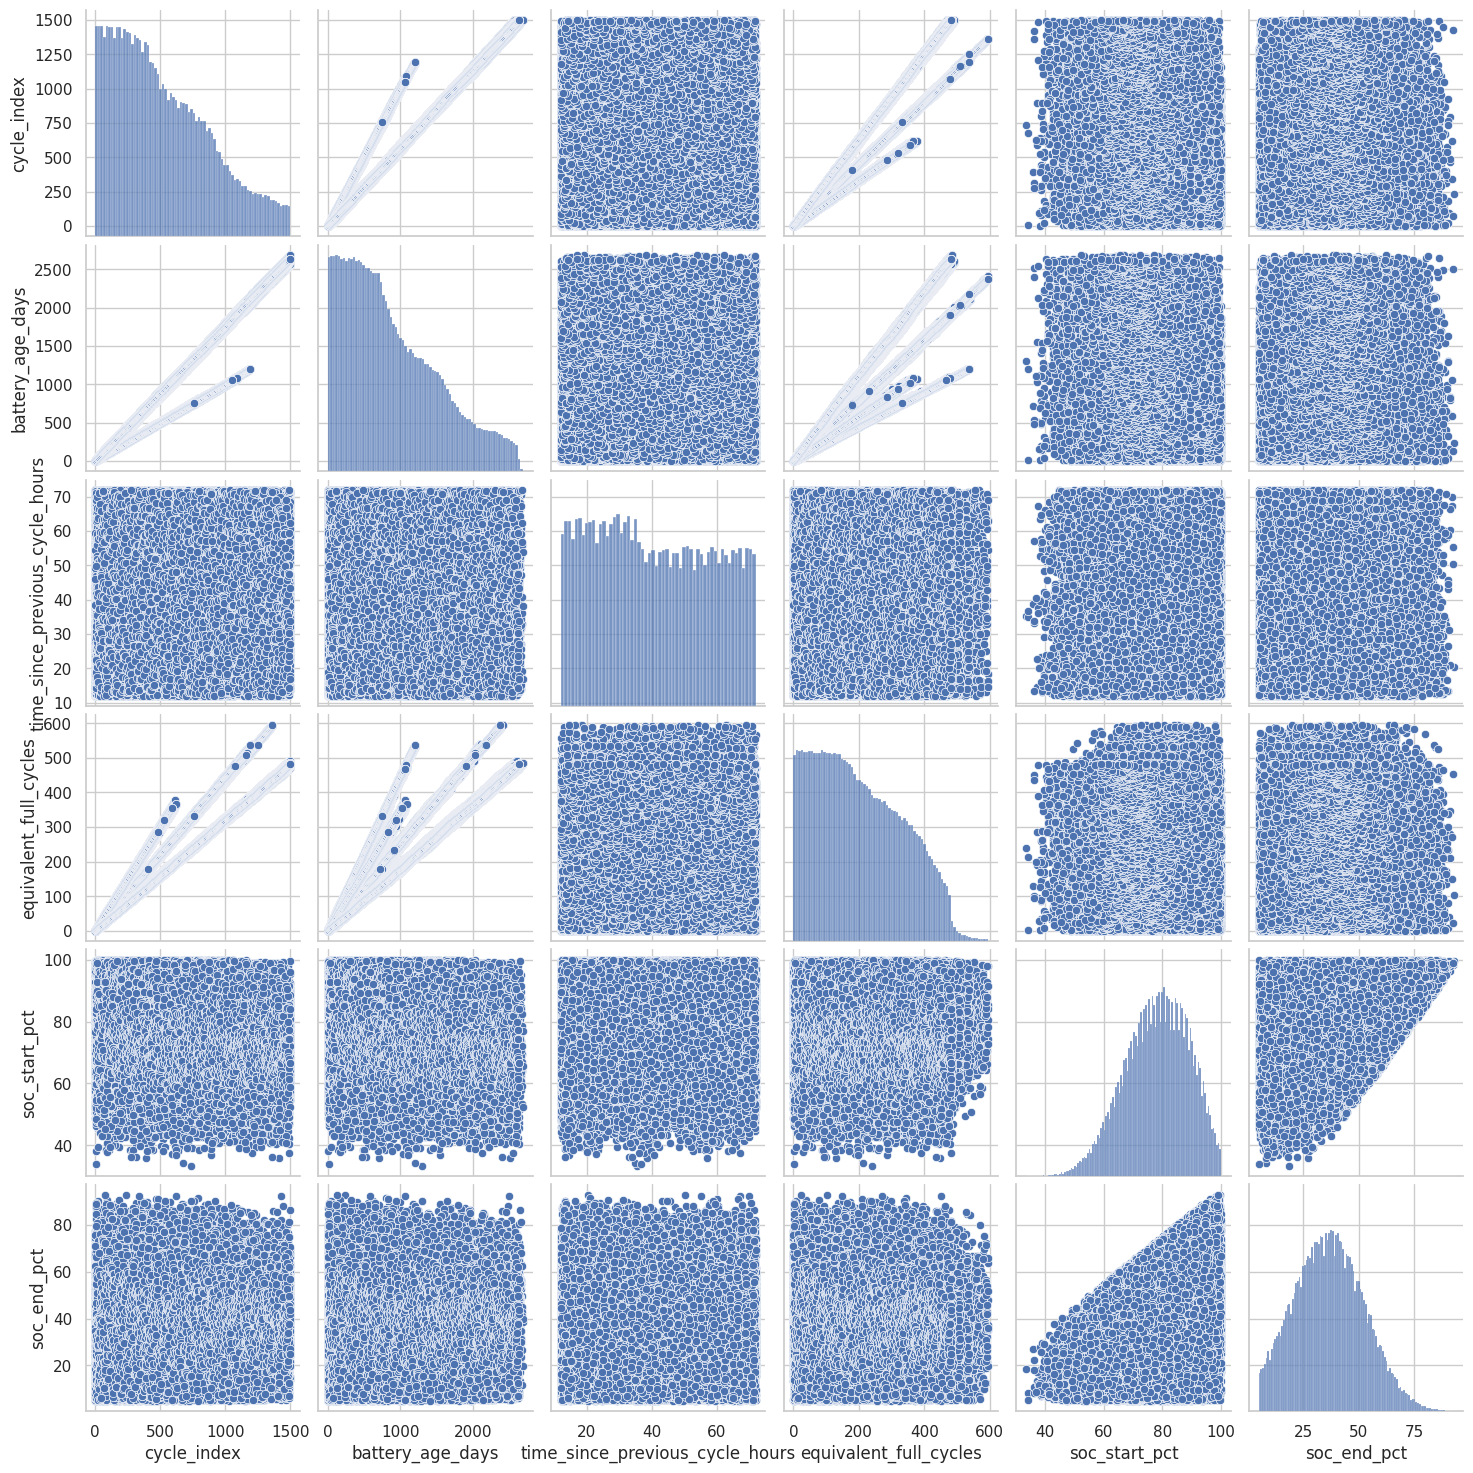

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(y='chemistry', data=battery_metadata, palette='viridis')
plt.title('Distribution of Battery Chemistry')
plt.tight_layout()
plt.show()

# For correlation analysis, select only numeric columns from battery observations
numeric_df = battery_obs_df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

# Pairplot for a subset of numeric features to visualize pairwise relationships
if numeric_df.shape[1] >= 4:
    sns.pairplot(numeric_df.iloc[:, :min(6, numeric_df.shape[1])])
    plt.show()

## Featute engineering

Random Forest model R^2 score: 1.00


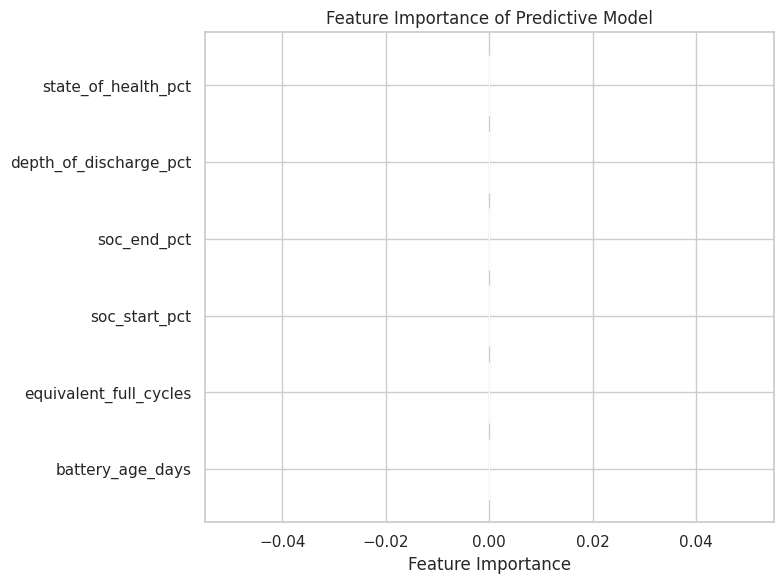

In [6]:
battery_last_cycle = battery_obs_df.sort_values('cycle_index').groupby('battery_id').tail(1).copy()

# Define the feature columns and target variable
feature_cols = ['battery_age_days', 'equivalent_full_cycles', 'soc_start_pct', 'soc_end_pct', 'depth_of_discharge_pct', 'state_of_health_pct']
target_col = 'remaining_useful_cycles'

# Check if the required columns exist
missing_features = [col for col in feature_cols + [target_col] if col not in battery_last_cycle.columns]
if missing_features:
    raise ValueError(f"Missing required columns for modelling: {missing_features}")

# Handle missing values by dropping rows with NaNs in either feature or target columns
battery_last_cycle = battery_last_cycle.dropna(subset=feature_cols + [target_col])

# Extract features and target
X = battery_last_cycle[feature_cols]
y = battery_last_cycle[target_col]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model using the R^2 score on the test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Random Forest model R^2 score: {r2:.2f}")

# Plot the feature importances using a horizontal bar chart
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(feature_cols)), importances[indices], align='center', color='mediumseagreen')
plt.yticks(range(len(feature_cols)), [feature_cols[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Feature Importance of Predictive Model')
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!